# From ARIMA to SARIMA ⏳: Handling Seasonality in Time Series 🌧️

## Quick Recap of ARIMA
- **Definition:** ARIMA = Auto-Regressive + Integrated + Moving Average  
- **Usage:** Works well for stationary series.  
- **Limitation:** Cannot naturally handle seasonality.  

- **Example to show:** A sales dataset with clear monthly or weekly repeating patterns where ARIMA struggles.

## Introduce Seasonality
- **Definition:** Regular, repeating patterns at fixed intervals (daily, weekly, yearly).  
- **Visualization:** Show a plot with clear seasonal spikes (e.g., ice cream sales peaking every summer).

## Why ARIMA Fails on Seasonal Data
- **Issue:** ARIMA tries to fit seasonality as noise → results in poor forecasts.  
- **Visualization:** Show ARIMA predictions missing seasonal peaks.
- Note: ARIMA is powerful, but not seasonal aware.

# SARIMA as an Extension

## Overview
SARIMA = **Seasonal ARIMA** = ARIMA + Seasonal Terms

## Full Specification
**Formula:** `SARIMA(p, d, q)(P, D, Q, m)`

### Non‑seasonal part (same as ARIMA)
- **p** — autoregression  
- **d** — differencing  
- **q** — moving average  

### Seasonal part
- **P** — seasonal autoregression  
- **D** — seasonal differencing  
- **Q** — seasonal moving average  
- **m** — length of season (e.g., 12 for monthly, 7 for weekly)

# ARIMA vs SARIMA — Comparison Table

## Model Capabilities

| Feature              | ARIMA | SARIMA |
|----------------------|:-----:|:------:|
| Handles trend        | ✔️    | ✔️     |
| Handles noise        | ✔️    | ✔️     |
| Handles seasonality  | ❌    | ✔️     |
| Parameters           | p, d, q | p, d, q + P, D, Q, m |




# Forecasting Daily Retail Orders with SARIMA  
### Modeling Weekly Seasonality for Smarter Inventory Planning

## Business Problem
A retail company receives hundreds of customer orders every day. The operations team has noticed a clear weekly cycle in demand:

- Orders **spike toward the end of the week** (e.g., Fridays).  
- Orders **dip at the start of the week** (e.g., Mondays).

The company previously relied on a basic **ARIMA** model. While ARIMA captured the average demand level, it produced a **flat forecast** that failed to reflect the weekly ups and downs.

## Why This Is a Problem
This lack of seasonal awareness made it difficult for managers to:

- Plan inventory replenishment efficiently.  
- Schedule warehouse staff according to high‑ and low‑demand days.  
- Reduce stock‑outs on peak days and avoid overstocking on slow days.

## Solution: Apply SARIMA
To address these challenges, the company will use **Seasonal ARIMA (SARIMA)**, which explicitly models **weekly seasonality (7‑day cycle)**.

This approach produces more realistic forecasts that reflect true demand patterns, enabling smarter, data‑driven operational planning.


In [1]:
# Import Libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
# Load the dataset

url = "Daily_Demand_Forecasting_Orders.csv"
df = pd.read_csv(url, sep = ";") #Semicolon - seperated file

In [3]:
df.head()

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
0,1,4,316.307,223.270,61.543,175.586,302.448,0.000,65556,44914,188411,14793,539.577
1,1,5,128.633,96.042,38.058,56.037,130.580,0.000,40419,21399,89461,7679,224.675
2,1,6,43.651,84.375,21.826,25.125,82.461,1.386,11992,3452,21305,14947,129.412
3,2,2,171.297,127.667,41.542,113.294,162.284,18.156,49971,33703,69054,18423,317.120
4,2,3,90.532,113.526,37.679,56.618,116.220,6.459,48534,19646,16411,20257,210.517


In [4]:
# Clean column name (space and special characters)

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex = False)
    .str.replace("(", "", regex = False)
    .str.replace(")", "", regex = False)
    .str.replace(";", "", regex = False)
)

print("Print column name after cleaning :", df.columns.tolist())

Print column name after cleaning : ['Week_of_the_month_first_week,_second,_third,_fourth_or_fifth_week', 'Day_of_the_week_Monday_to_Friday', 'Non-urgent_order', 'Urgent_order', 'Order_type_A', 'Order_type_B', 'Order_type_C', 'Fiscal_sector_orders', 'Orders_from_the_traffic_controller_sector', 'Banking_orders_1', 'Banking_orders_2', 'Banking_orders_3', 'Target_Total_orders']


In [7]:
# Add Dates Index (Simulate daily dates)

df["Date"] = pd.date_range(start = "2025-06-1", periods = len(df), freq = "D")
df.set_index("Date", inplace = True)

In [8]:
df.head()

,"Week_of_the_month_first_week,_second,_third,_fourth_or_fifth_week",Day_of_the_week_Monday_to_Friday,Non-urgent_order,Urgent_order,Order_type_A,Order_type_B,Order_type_C,Fiscal_sector_orders,Orders_from_the_traffic_controller_sector,Banking_orders_1,Banking_orders_2,Banking_orders_3,Target_Total_orders
Date,,,,,,,,,,,,,
2025-06-01,1,4,316.307,223.270,61.543,175.586,302.448,0.000,65556,44914,188411,14793,539.577
2025-06-02,1,5,128.633,96.042,38.058,56.037,130.580,0.000,40419,21399,89461,7679,224.675
2025-06-03,1,6,43.651,84.375,21.826,25.125,82.461,1.386,11992,3452,21305,14947,129.412
2025-06-04,2,2,171.297,127.667,41.542,113.294,162.284,18.156,49971,33703,69054,18423,317.120
2025-06-05,2,3,90.532,113.526,37.679,56.618,116.220,6.459,48534,19646,16411,20257,210.517


In [9]:
len(df)

60

In [10]:
df.shape

(60, 13)

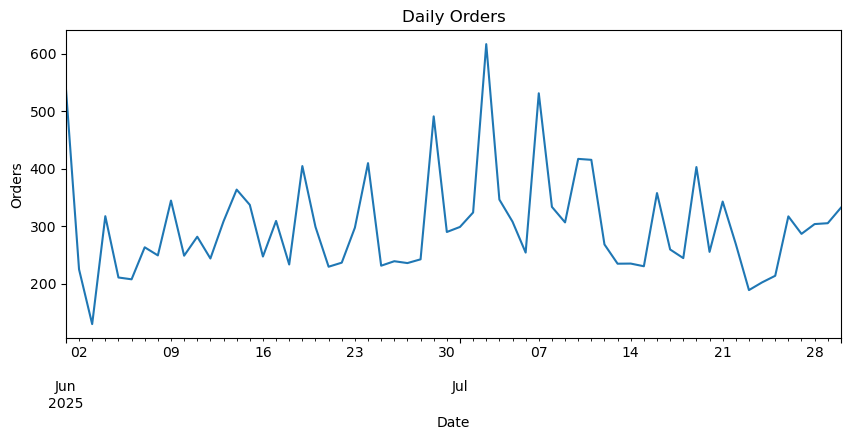

In [12]:
# Target Series = Total Orders

ts = df["Target_Total_orders"]
ts.plot(figsize = (10,4), title = "Daily Orders")
plt.ylabel("Orders")
plt.show()

In [13]:
# Stationary Test

adf_result = adfuller(ts)
print("ADF Statistics : %.3f, p-value : %.3f" % (adf_result[0],adf_result[1]))

ADF Statistics : -7.495, p-value : 0.000


In [15]:
# Fit SARIMA (Weakly Seasonality , m =7)
# We will start the SARIMA with (1,1,1)(1,1,1,7)
# Ensure datetime index have frequency

ts = ts.asfreq("D")  # "D"-> Daily, "W" -> Weekly, "M" -> Monthly

# now fit SARIMA
model = sm.tsa.SARIMAX(ts,
                    order = (1,1,1),
                    seasonal_order= (1,1,1,7),
                    enforce_stationarity= False,
                    enforce_invertibility= False
                   )

result = model.fit()
print(result.summary())


                                     SARIMAX Results                                     
Dep. Variable:               Target_Total_orders   No. Observations:                   60
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -260.488
Date:                           Thu, 30 Jul 2026   AIC                            530.977
Time:                                   15:02:47   BIC                            539.783
Sample:                               06-01-2025   HQIC                           534.224
                                    - 07-30-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0119      0.200     -0.059      0.953      -0.404       0.380
ma.L1         -0.8283      0.137     -6.066

## Observation

AIC and BIC are information criteria - the lower their value, the better the model balances fit and complexity.

---

## Diagnostics

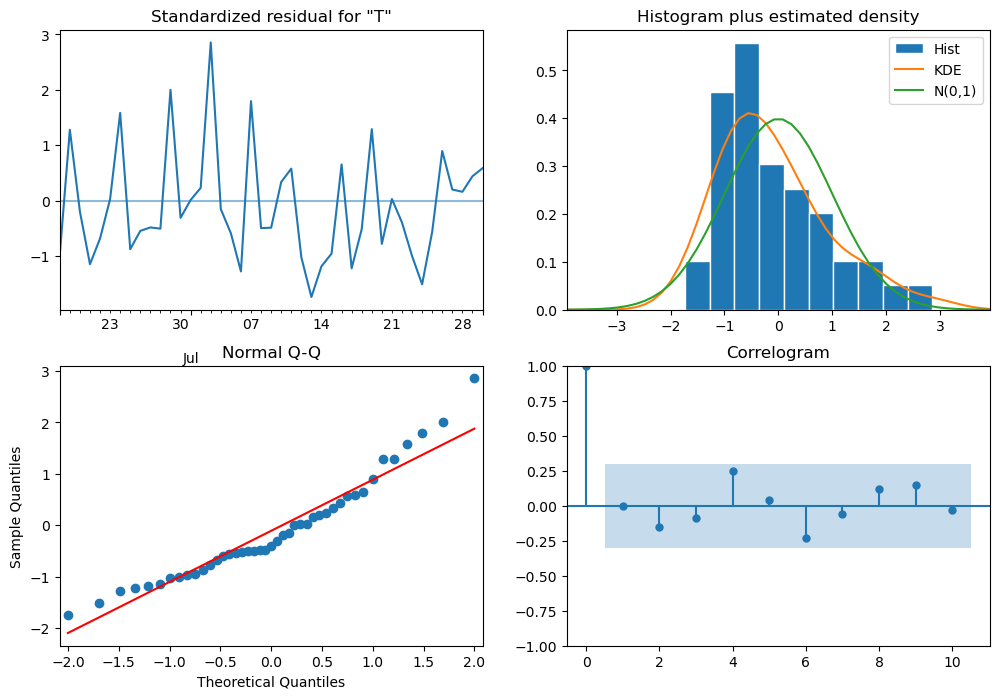

In [17]:
result.plot_diagnostics(figsize = (12,8))
plt.show()

## Observation

### Residual Diagnostics Summary

- **Top‑Left (Standardized Residuals):**  
  Residuals bounce randomly around zero, indicating the model has captured most underlying patterns.

- **Top‑Right (Histogram + KDE):**  
  Residuals appear roughly bell‑shaped, suggesting the errors resemble a normal distribution.

- **Bottom‑Left (Normal Q‑Q):**  
  Points lie close to the red reference line, showing residuals follow normality fairly well.

- **Bottom‑Right (Correlogram):**  
  No significant spikes outside the blue band, meaning residuals are not autocorrelated.


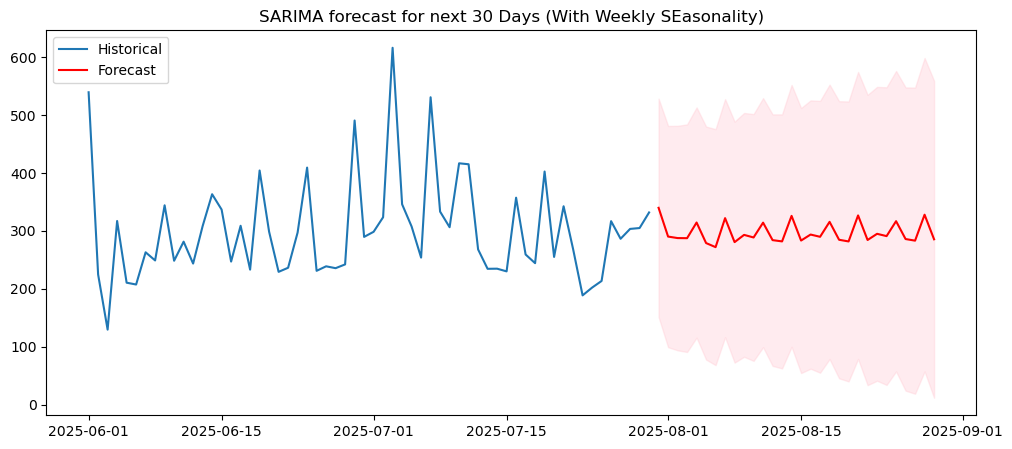

In [19]:
# Forecast for next 30 Days

forecast_setps =30
forecast = result.get_forecast( steps = forecast_setps)
forecast_df = forecast.summary_frame()

# Plot Forecast

plt.figure(figsize = (12,5))
plt.plot(ts, label = "Historical")
plt.plot(forecast_df.index, forecast_df["mean"], label = "Forecast", color = "red")
plt.fill_between(forecast_df.index,
                 forecast_df["mean_ci_lower"],
                 forecast_df["mean_ci_upper"],
                 color = "pink", alpha = 0.3)
plt.legend()
plt.title(f"SARIMA forecast for next {forecast_setps} Days (With Weekly SEasonality)")
plt.show()

## Observation

### SARIMA Forecast Interpretation

- **Historical vs Forecast:**  
  The blue line represents the historical data, while the red line shows the SARIMA forecast for the next 30 days.

- **Seasonal Pattern:**  
  The forecast continues to follow a weekly seasonal pattern, consistent with the observed behavior in the data.

- **Confidence Interval:**  
  The shaded region indicates the confidence interval — the possible range of future values. A wider interval reflects higher uncertainty.

---

## Step 9: Backtesting on last 15 days


In [20]:
# Split data

train, test = ts[:-15], ts[-15:]

# Reassign frequenct (Assuming Daily Data)

train = train.asfreq("D")
test = test.asfreq("D")

# now fit SARIMA
model_bt = sm.tsa.SARIMAX(ts,
                    order = (1,1,1),
                    seasonal_order= (1,1,1,7),
                    enforce_stationarity= False,
                    enforce_invertibility= False
                   )

result_bt = model_bt.fit()
pred_bt = result_bt.forecast(steps=15)

In [21]:

mae = mean_absolute_error(test, pred_bt)
rmse = np.sqrt(mean_squared_error(test, pred_bt))
mape = np.mean(np.abs((test - pred_bt) / test)) * 100
print(f"Backtest → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")


Backtest → MAE: 48.64, RMSE: 61.56, MAPE: nan%


In [24]:
print("\n=== Forecast Summary ===")
print("Model: SARIMA(1,1,1)(1,1,1,7)")
print(f"Forecast horizon: next {forecast_setps} days")
print(f"First day forecast: {forecast_df['mean'].iloc[0]:.0f} orders "
      f"(range {forecast_df['mean_ci_lower'].iloc[0]:.0f} – {forecast_df['mean_ci_upper'].iloc[0]:.0f})")


=== Forecast Summary ===
Model: SARIMA(1,1,1)(1,1,1,7)
Forecast horizon: next 30 days
First day forecast: 340 orders (range 151 – 529)


## BackTest

In [26]:
# Split data
train, test = ts[:-forecast_setps], ts[-forecast_setps:]

# Re-assign frequency (assuming daily data)
train = train.asfreq('D')
test  = test.asfreq('D')

# ARIMA model

model_bt = sm.tsa.ARIMA(train, order=(1,1,1))
results_bt = model_bt.fit()
pred_bt = results_bt.forecast(steps=forecast_setps)

# Metrics

mae = mean_absolute_error(test, pred_bt)
rmse = np.sqrt(mean_squared_error(test, pred_bt))
mape = np.mean(np.abs((test - pred_bt) / test)) * 100

print(f'Backtest → MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%')


Backtest → MAE: 65.46, RMSE: 94.70, MAPE: 19.54%


### Observation

Backtesting isn’t just about one score — it helps us see how stable the model is across different time periods.

### Summary

👉 SARIMA not only captures trend and randomness like ARIMA, but also models repeating seasonal patterns.

👉 With it, we can generate realistic forecasts along with uncertainty bands, making the model more useful for business decisions.